In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_excel(r"/Users/developer/Documents/Current Project/Python/DevArena /Arena-Week-8-CapstoneProject/data/raw_data.xlsx", sheet_name="Year 2010-2011")
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [21]:
df_original = df.copy()

In [22]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[us]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


splitting the date

In [23]:
df_original['InvoiceDate'] = pd.to_datetime(df_original['InvoiceDate'])
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[us]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [24]:
df_original['Invoice_Date'] = df_original['InvoiceDate'].dt.date
df_original['Invoice_Time'] = df_original['InvoiceDate'].dt.time
df_original.drop(columns=['InvoiceDate'], axis="columns", inplace=True)
df_original

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,Invoice_Date,Invoice_Time
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010-12-01,08:26:00
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010-12-01,08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
...,...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,France,2011-12-09,12:50:00
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,France,2011-12-09,12:50:00
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,France,2011-12-09,12:50:00
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,4.95,12680.0,France,2011-12-09,12:50:00


In [25]:
df_original[['Year', 'Month', 'Day']] = df_original['Invoice_Date'].astype(str).str.split("-", expand=True)
df_original.drop(columns=['Invoice_Date'], axis="columns", inplace=True)
df_original

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,Invoice_Time,Year,Month,Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,08:26:00,2010,12,01
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,08:26:00,2010,12,01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,08:26:00,2010,12,01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,08:26:00,2010,12,01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,08:26:00,2010,12,01
...,...,...,...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,France,12:50:00,2011,12,09
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,France,12:50:00,2011,12,09
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,France,12:50:00,2011,12,09
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,4.95,12680.0,France,12:50:00,2011,12,09


add line sale column

In [26]:
df_original['LineSale'] = df_original['Quantity'] * df_original['Price']
df_original

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,Invoice_Time,Year,Month,Day,LineSale
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,08:26:00,2010,12,01,15.30
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,08:26:00,2010,12,01,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,08:26:00,2010,12,01,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,08:26:00,2010,12,01,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,08:26:00,2010,12,01,20.34
...,...,...,...,...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,France,12:50:00,2011,12,09,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,France,12:50:00,2011,12,09,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,France,12:50:00,2011,12,09,16.60
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,4.95,12680.0,France,12:50:00,2011,12,09,14.85


In [27]:
df_original = df_original[~(df_original['Customer ID'].isna())]

In [28]:
df_original.isnull().sum()

Invoice         0
StockCode       0
Description     0
Quantity        0
Price           0
Customer ID     0
Country         0
Invoice_Time    0
Year            0
Month           0
Day             0
LineSale        0
dtype: int64

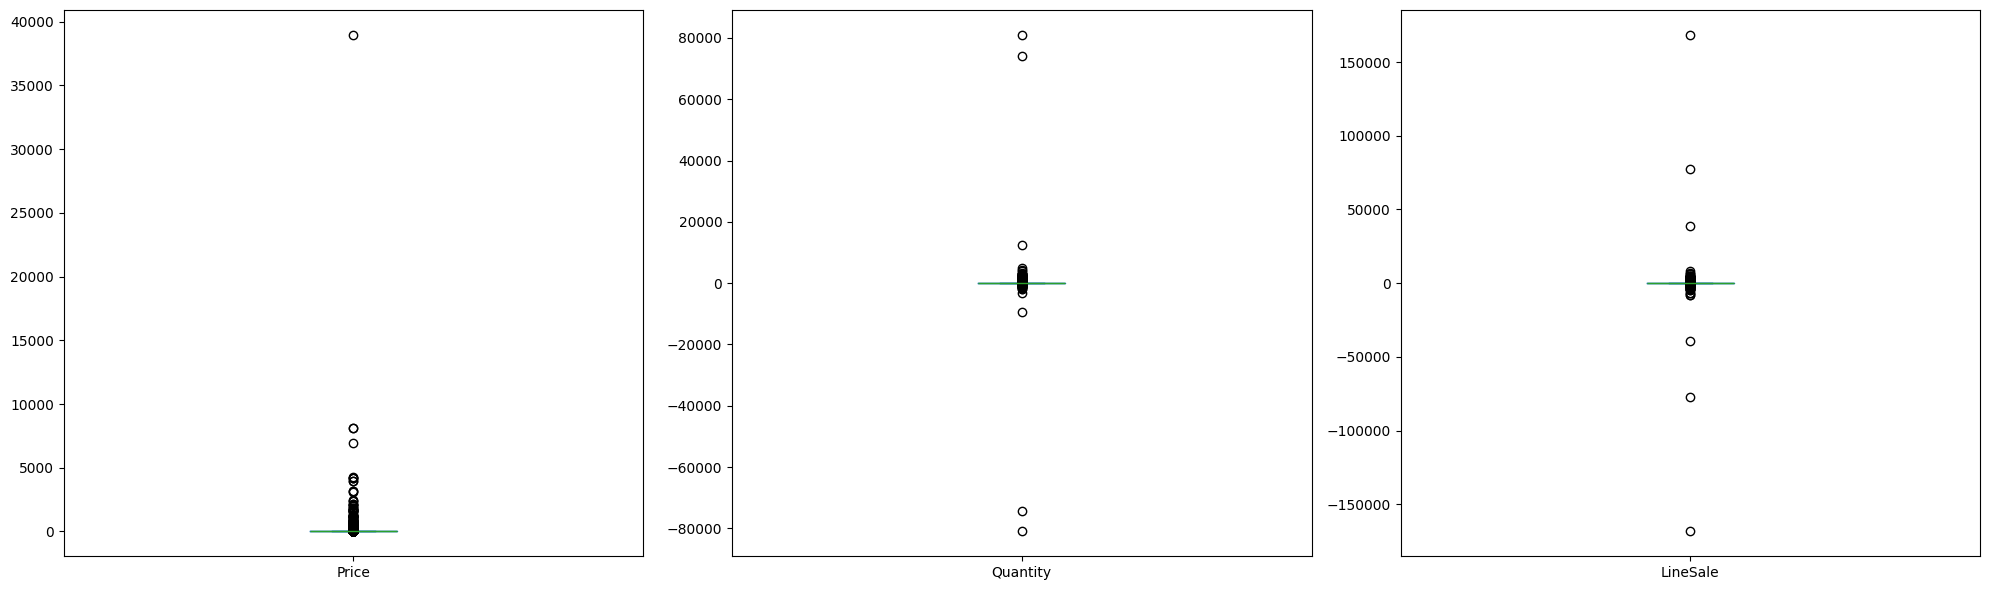

In [29]:
plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
df_original['Price'].plot(kind='box')
plt.subplot(1, 3, 2)
df_original['Quantity'].plot(kind='box')
plt.subplot(1, 3, 3)
df_original['LineSale'].plot(kind='box')
plt.tight_layout()
plt.show()

In [30]:
df_original[df_original['Quantity'] < 0] 

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,Invoice_Time,Year,Month,Day,LineSale
141,C536379,D,Discount,-1,27.50,14527.0,United Kingdom,09:41:00,2010,12,01,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,4.65,15311.0,United Kingdom,09:49:00,2010,12,01,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,1.65,17548.0,United Kingdom,10:24:00,2010,12,01,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29,17548.0,United Kingdom,10:24:00,2010,12,01,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29,17548.0,United Kingdom,10:24:00,2010,12,01,-6.96
...,...,...,...,...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,0.83,14397.0,United Kingdom,09:57:00,2011,12,09,-9.13
541541,C581499,M,Manual,-1,224.69,15498.0,United Kingdom,10:28:00,2011,12,09,-224.69
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,10.95,15311.0,United Kingdom,11:57:00,2011,12,09,-54.75
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,1.25,17315.0,United Kingdom,11:58:00,2011,12,09,-1.25


In [31]:
col_list = ['Quantity', 'Price', 'LineSale']
for col in col_list:
    Q1 = df_original[col].quantile(0.25)
    Q3 = df_original[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_original = df_original[(df_original[col] >= lower_bound) & (df_original[col] <= upper_bound)]

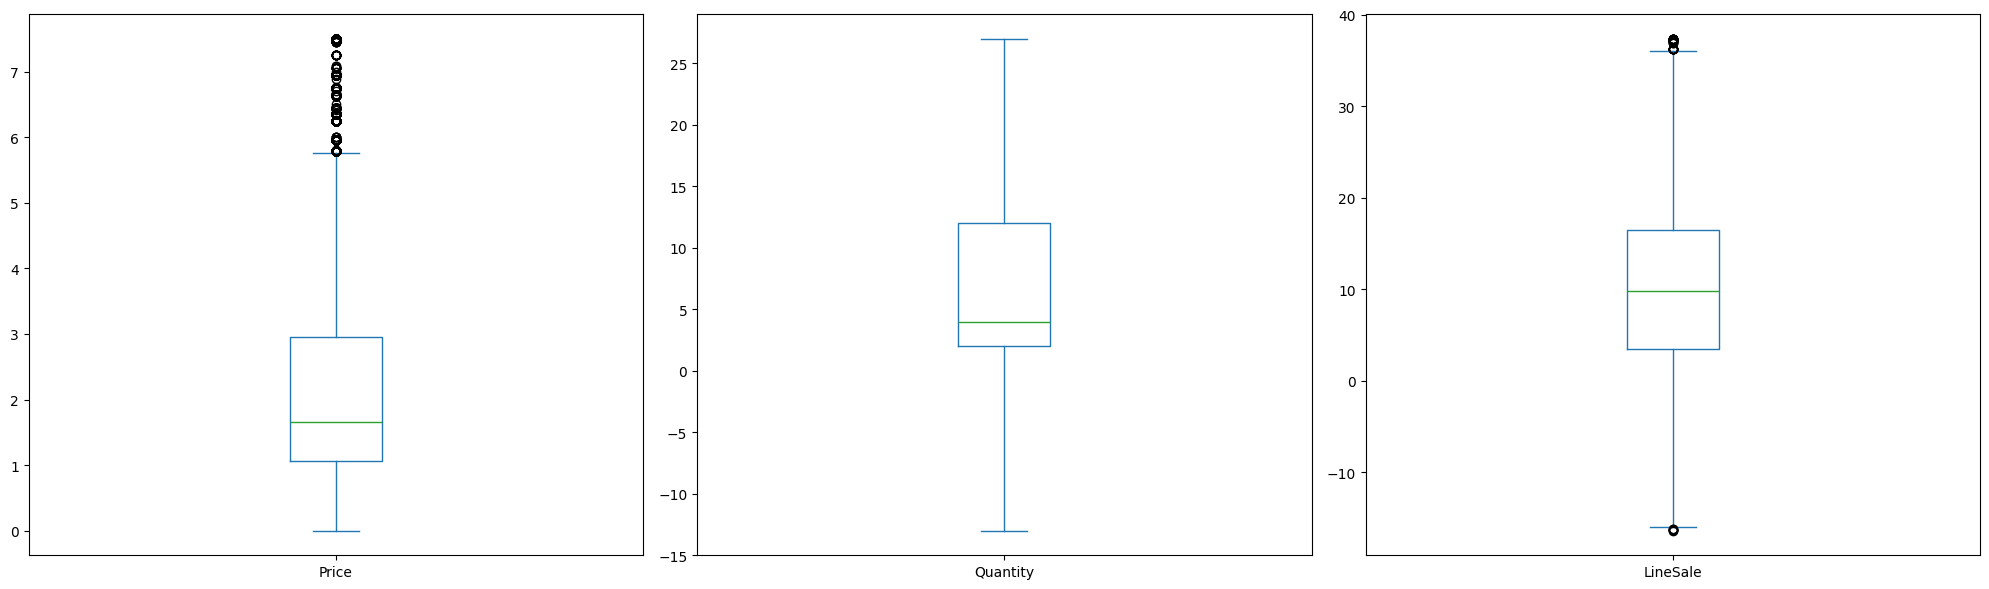

In [32]:
plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
df_original['Price'].plot(kind='box')
plt.subplot(1, 3, 2)
df_original['Quantity'].plot(kind='box')
plt.subplot(1, 3, 3)
df_original['LineSale'].plot(kind='box')
plt.tight_layout()
plt.show()

In [33]:
df_original = df_original[(df_original['Quantity']>0) & (df_original['LineSale']>0)]

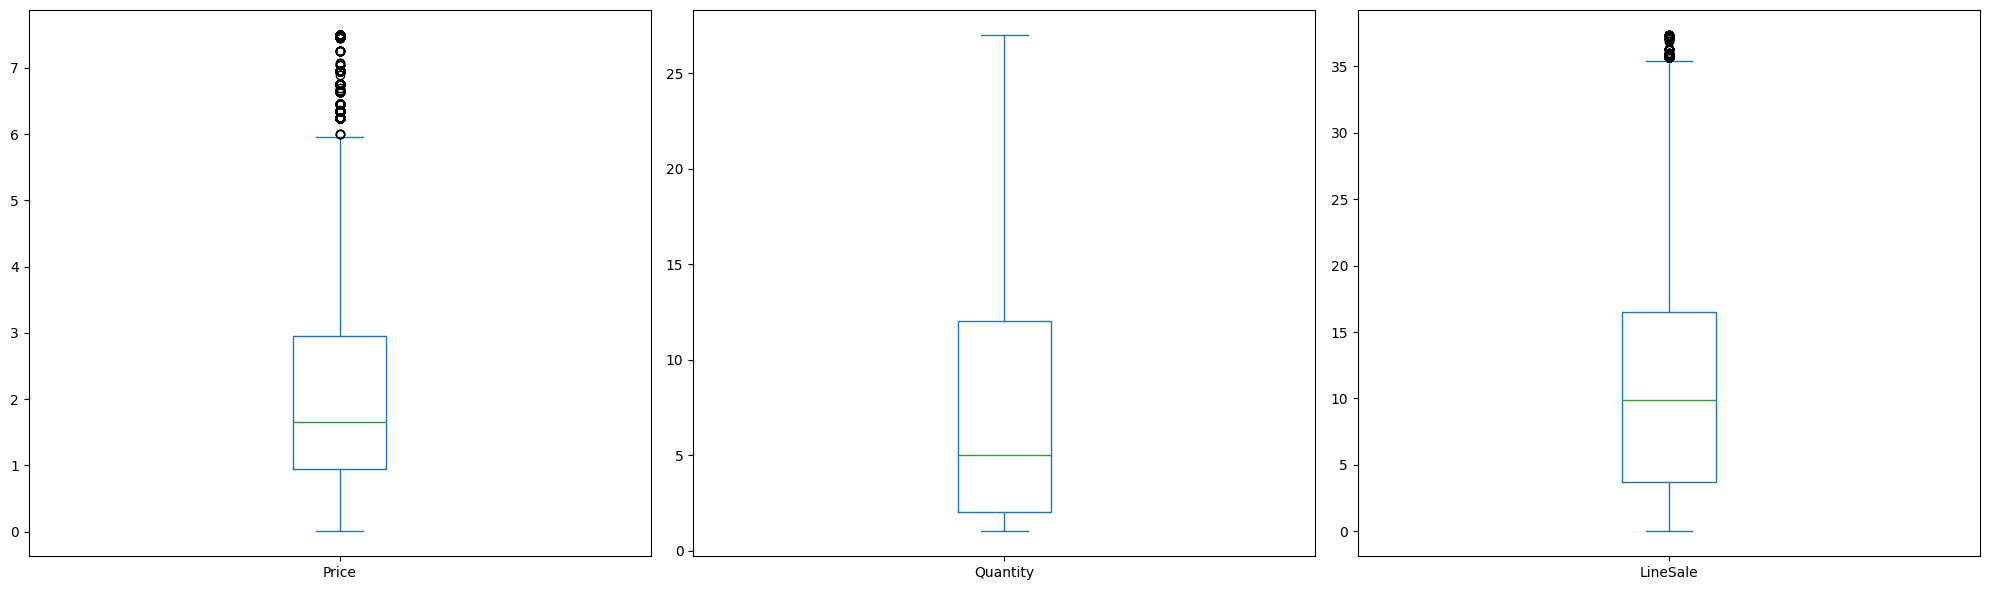

In [34]:
plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
df_original['Price'].plot(kind='box')
plt.subplot(1, 3, 2)
df_original['Quantity'].plot(kind='box')
plt.subplot(1, 3, 3)
df_original['LineSale'].plot(kind='box')
plt.tight_layout()
plt.show()

In [35]:
df_original

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,Invoice_Time,Year,Month,Day,LineSale
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,08:26:00,2010,12,01,15.30
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,08:26:00,2010,12,01,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,08:26:00,2010,12,01,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,08:26:00,2010,12,01,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,08:26:00,2010,12,01,20.34
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,France,12:50:00,2011,12,09,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,France,12:50:00,2011,12,09,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,France,12:50:00,2011,12,09,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,France,12:50:00,2011,12,09,16.60


In [36]:
df_original.drop(['Description'], axis="columns", inplace=True)

In [37]:
region_map = {
    'United Kingdom': 'Europe',
    'France': 'Europe',
    'Germany': 'Europe',
    'Italy': 'Europe',
    'Spain': 'Europe',
    'Netherlands': 'Europe',
    'Belgium': 'Europe',
    'Switzerland': 'Europe',
    'Portugal': 'Europe',
    'Norway': 'Europe',
    'Sweden': 'Europe',
    'Denmark': 'Europe',
    'Finland': 'Europe',
    'Poland': 'Europe',
    'Austria': 'Europe',
    'Greece': 'Europe',
    'Ireland': 'Europe',
    'Iceland': 'Europe',
    'Czech Republic': 'Europe',
    'Lithuania': 'Europe',

    'Saudi Arabia': 'Middle East',
    'United Arab Emirates': 'Middle East',
    'Israel': 'Middle East',
    'Bahrain': 'Middle East',

    'Japan': 'Asia',
    'Singapore': 'Asia',

    'USA': 'North America',
    'Canada': 'North America',

    'Australia': 'Oceania',

    'Brazil': 'South America',

    'RSA': 'Africa',

    'Unspecified': 'Other',
    'European Community': 'Europe',
    'Channel Islands': 'Europe',
    'Lebanon': 'Middle East',
    'Cyprus': 'Middle East'
}

In [38]:
df_original['Region'] = df_original['Country'].map(region_map)

In [46]:
df_original

,Invoice,StockCode,Quantity,Price,Customer ID,Country,Invoice_Time,Year,Month,Day,LineSale,Region
0,536365,85123A,6,2.55,17850.0,United Kingdom,08:26:00,2010,12,01,15.30,Europe
1,536365,71053,6,3.39,17850.0,United Kingdom,08:26:00,2010,12,01,20.34,Europe
2,536365,84406B,8,2.75,17850.0,United Kingdom,08:26:00,2010,12,01,22.00,Europe
3,536365,84029G,6,3.39,17850.0,United Kingdom,08:26:00,2010,12,01,20.34,Europe
4,536365,84029E,6,3.39,17850.0,United Kingdom,08:26:00,2010,12,01,20.34,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,12,0.85,12680.0,France,12:50:00,2011,12,09,10.20,Europe
541905,581587,22899,6,2.10,12680.0,France,12:50:00,2011,12,09,12.60,Europe
541906,581587,23254,4,4.15,12680.0,France,12:50:00,2011,12,09,16.60,Europe
541907,581587,23255,4,4.15,12680.0,France,12:50:00,2011,12,09,16.60,Europe


In [42]:
df_original.to_excel(r"/Users/developer/Documents/Current Project/Python/DevArena /Arena-Week-8-CapstoneProject/data/cleaned_data.xlsx", index=False)